In [1]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Load dataset

file_path = "sales_data.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (76000, 16)


In [3]:
# Basic structure

df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


In [4]:
# Convert Date to datetime

df["Date"] = pd.to_datetime(df["Date"])

print("Date type:", df["Date"].dtype)
print("Date range:", df["Date"].min(), "to", df["Date"].max())

Date type: datetime64[ns]
Date range: 2022-01-01 00:00:00 to 2024-01-30 00:00:00


## 1. Data Quality Validation

In [5]:
# Missing values

missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing %": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_summary

,Missing Values,Missing %
Date,0,0.0
Store ID,0,0.0
Product ID,0,0.0
Category,0,0.0
Region,0,0.0
Inventory Level,0,0.0
Units Sold,0,0.0
Units Ordered,0,0.0
Price,0,0.0
Discount,0,0.0


In [6]:
# Duplicate rows

duplicates = df.duplicated().sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 0


In [7]:
# Check data types

df.dtypes

Date                  datetime64[ns]
Store ID                      object
Product ID                    object
Category                      object
Region                        object
Inventory Level                int64
Units Sold                     int64
Units Ordered                  int64
Price                        float64
Discount                       int64
Weather Condition             object
Promotion                      int64
Competitor Pricing           float64
Seasonality                   object
Epidemic                       int64
Demand                         int64
dtype: object

In [8]:
# Check for negative values in important numerical columns

numeric_columns = [
    "Inventory Level",
    "Units Sold",
    "Units Ordered",
    "Price",
    "Discount",
    "Competitor Pricing",
    "Demand"
]

negative_values = {}

for column in numeric_columns:
    negative_values[column] = (df[column] < 0).sum()

pd.Series(negative_values, name="Negative Value Count")

Inventory Level       0
Units Sold            0
Units Ordered         0
Price                 0
Discount              0
Competitor Pricing    0
Demand                0
Name: Negative Value Count, dtype: int64

In [9]:
# Check logical relationships

print("Rows where Units Sold > Inventory Level:")
print((df["Units Sold"] > df["Inventory Level"]).sum())

print("\nRows where Units Ordered < 0:")
print((df["Units Ordered"] < 0).sum())

print("\nRows where Demand < 0:")
print((df["Demand"] < 0).sum())

Rows where Units Sold > Inventory Level:
0

Rows where Units Ordered < 0:
0

Rows where Demand < 0:
0


## 2. Standardize Categorical Columns

In [10]:
# Remove accidental leading/trailing spaces from text columns

text_columns = [
    "Store ID",
    "Product ID",
    "Category",
    "Region",
    "Weather Condition",
    "Promotion",
    "Seasonality",
    "Epidemic"
]

for column in text_columns:
    df[column] = df[column].astype(str).str.strip()

print("Categorical/text columns standardized.")

Categorical/text columns standardized.


In [11]:
# Verify categorical values

for column in ["Category", "Region", "Weather Condition", "Promotion", "Seasonality", "Epidemic"]:
    print(f"\n{column}:")
    print(df[column].value_counts())


Category:
Category
Groceries      30400
Furniture      13680
Clothing       12160
Toys           10640
Electronics     9120
Name: count, dtype: int64

Region:
Region
North    30400
South    15200
East     15200
West     15200
Name: count, dtype: int64

Weather Condition:
Weather Condition
Cloudy    24360
Sunny     22980
Rainy     17500
Snowy     11160
Name: count, dtype: int64

Promotion:
Promotion
0    51000
1    25000
Name: count, dtype: int64

Seasonality:
Seasonality
Winter    21000
Spring    18400
Summer    18400
Autumn    18200
Name: count, dtype: int64

Epidemic:
Epidemic
0    60800
1    15200
Name: count, dtype: int64


## 3. Create Date Features

In [12]:
# Date features

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.month_name()
df["Week"] = df["Date"].dt.isocalendar().week.astype(int)
df["Day"] = df["Date"].dt.day
df["Day_Name"] = df["Date"].dt.day_name()
df["Day_of_Week"] = df["Date"].dt.dayofweek
df["Quarter"] = df["Date"].dt.quarter

df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand,Year,Month,Month_Name,Week,Day,Day_Name,Day_of_Week,Quarter
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115,2022,1,January,52,1,Saturday,5,1
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229,2022,1,January,52,1,Saturday,5,1
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157,2022,1,January,52,1,Saturday,5,1
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52,2022,1,January,52,1,Saturday,5,1
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59,2022,1,January,52,1,Saturday,5,1


## 4. Sales & Revenue KPIs

In [13]:
# Revenue

df["Revenue"] = df["Units Sold"] * df["Price"]

df[["Units Sold", "Price", "Revenue"]].head()

,Units Sold,Price,Revenue
0,102,72.72,7417.44
1,117,80.16,9378.72
2,114,62.94,7175.16
3,45,87.63,3943.35
4,65,54.41,3536.65


In [14]:
# Revenue after discount

# Discount is treated as a percentage.
# Example: Discount = 10 means a 10% discount.

df["Discounted_Price"] = df["Price"] * (1 - df["Discount"] / 100)

df["Net_Revenue"] = df["Units Sold"] * df["Discounted_Price"]

df[[
    "Price",
    "Discount",
    "Discounted_Price",
    "Units Sold",
    "Net_Revenue"
]].head()

,Price,Discount,Discounted_Price,Units Sold,Net_Revenue
0,72.72,5,69.084,102,7046.568
1,80.16,15,68.136,117,7971.912
2,62.94,10,56.646,114,6457.644
3,87.63,10,78.867,45,3549.015
4,54.41,0,54.410,65,3536.650


In [15]:
# Basic sales KPIs

total_units_sold = df["Units Sold"].sum()
total_demand = df["Demand"].sum()
total_revenue = df["Revenue"].sum()
total_net_revenue = df["Net_Revenue"].sum()

print("Total Units Sold:", total_units_sold)
print("Total Demand:", total_demand)
print("Total Revenue:", round(total_revenue, 2))
print("Total Net Revenue:", round(total_net_revenue, 2))

Total Units Sold: 6750876
Total Demand: 7928104
Total Revenue: 455300094.5
Total Net Revenue: 412590589.82


## 5. Inventory KPIs

In [16]:
# Inventory value

df["Inventory_Value"] = df["Inventory Level"] * df["Price"]

df[[
    "Inventory Level",
    "Price",
    "Inventory_Value"
]].head()

,Inventory Level,Price,Inventory_Value
0,195,72.72,14180.40
1,117,80.16,9378.72
2,247,62.94,15546.18
3,139,87.63,12180.57
4,152,54.41,8270.32


In [17]:
# Inventory coverage based on same-day demand

# This is an exploratory measure.
# Later we will calculate a more robust coverage measure using
# average/forecast demand.

df["Inventory_Demand_Coverage"] = np.where(
    df["Demand"] > 0,
    df["Inventory Level"] / df["Demand"],
    np.nan
)

df[[
    "Inventory Level",
    "Demand",
    "Inventory_Demand_Coverage"
]].head()

,Inventory Level,Demand,Inventory_Demand_Coverage
0,195,115,1.695652
1,117,229,0.510917
2,247,157,1.573248
3,139,52,2.673077
4,152,59,2.576271


In [18]:
# Inventory-to-sales ratio

df["Inventory_to_Sales_Ratio"] = np.where(
    df["Units Sold"] > 0,
    df["Inventory Level"] / df["Units Sold"],
    np.nan
)

df[[
    "Inventory Level",
    "Units Sold",
    "Inventory_to_Sales_Ratio"
]].head()

,Inventory Level,Units Sold,Inventory_to_Sales_Ratio
0,195,102,1.911765
1,117,117,1.000000
2,247,114,2.166667
3,139,45,3.088889
4,152,65,2.338462


## 6. Supply / Replenishment KPIs

In [19]:
# Order fulfillment ratio

# Compares units ordered with units sold.
# This is an exploratory supply indicator, not a supplier fill-rate metric.

df["Order_to_Sales_Ratio"] = np.where(
    df["Units Sold"] > 0,
    df["Units Ordered"] / df["Units Sold"],
    np.nan
)

df[[
    "Units Ordered",
    "Units Sold",
    "Order_to_Sales_Ratio"
]].head()

,Units Ordered,Units Sold,Order_to_Sales_Ratio
0,252,102,2.470588
1,249,117,2.128205
2,612,114,5.368421
3,102,45,2.266667
4,271,65,4.169231


In [20]:
# Net inventory movement indicator

# Positive value: more units ordered than sold.
# Negative value: more units sold than ordered.

df["Order_Sales_Gap"] = df["Units Ordered"] - df["Units Sold"]

df[[
    "Units Ordered",
    "Units Sold",
    "Order_Sales_Gap"
]].head()

,Units Ordered,Units Sold,Order_Sales_Gap
0,252,102,150
1,249,117,132
2,612,114,498
3,102,45,57
4,271,65,206


## 7. Initial Stockout Indicators

In [21]:
# Stockout flag

# Initial transparent rule:
# Inventory Level == 0 means the observed inventory position is a stockout.

df["Stockout_Flag"] = np.where(
    df["Inventory Level"] <= 0,
    1,
    0
)

print("Stockout records:", df["Stockout_Flag"].sum())
print("Stockout rate:", round(df["Stockout_Flag"].mean() * 100, 2), "%")

Stockout records: 406
Stockout rate: 0.53 %


In [22]:
# Demand pressure flag

# Indicates that demand is greater than the currently observed inventory.

df["Demand_Exceeds_Inventory"] = np.where(
    df["Demand"] > df["Inventory Level"],
    1,
    0
)

print(
    "Records where demand exceeds inventory:",
    df["Demand_Exceeds_Inventory"].sum()
)

print(
    "Rate:",
    round(df["Demand_Exceeds_Inventory"].mean() * 100, 2),
    "%"
)

Records where demand exceeds inventory: 10394
Rate: 13.68 %


## 8. Initial Overstock Indicators

In [23]:
# Initial overstock rule

# We use a simple exploratory threshold:
# inventory coverage greater than 3 units of observed demand.

df["Initial_Overstock_Flag"] = np.where(
    df["Inventory_Demand_Coverage"] > 3,
    1,
    0
)

print(
    "Initial overstock records:",
    df["Initial_Overstock_Flag"].sum()
)

print(
    "Initial overstock rate:",
    round(df["Initial_Overstock_Flag"].mean() * 100, 2),
    "%"
)

Initial overstock records: 31894
Initial overstock rate: 41.97 %


### Why this is only an initial rule

The `> 3` coverage threshold is **not our final optimization rule**.

Later we will replace/refine it using:
- forecast demand
- demand variability
- lead time
- safety stock
- reorder point

This keeps the analysis transparent and prevents us from pretending that an arbitrary threshold is an optimal inventory policy.

## 9. Initial Inventory Risk Classification

In [24]:
# Initial risk classification

def classify_inventory_risk(row):
    if row["Stockout_Flag"] == 1:
        return "Stockout"
    elif row["Demand_Exceeds_Inventory"] == 1:
        return "Low Inventory"
    elif row["Initial_Overstock_Flag"] == 1:
        return "Overstock"
    else:
        return "Healthy"

df["Initial_Inventory_Risk"] = df.apply(
    classify_inventory_risk,
    axis=1
)

df["Initial_Inventory_Risk"].value_counts()

Initial_Inventory_Risk
Healthy          33712
Overstock        31894
Low Inventory     9988
Stockout           406
Name: count, dtype: int64

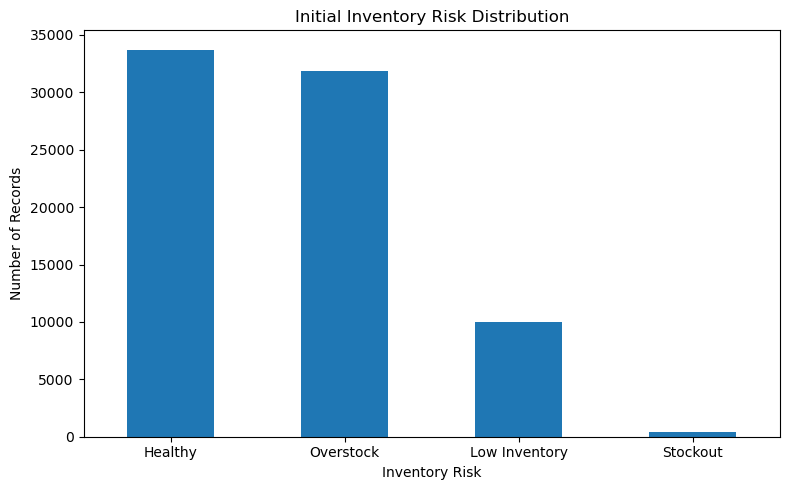

In [25]:
# Risk distribution

risk_counts = df["Initial_Inventory_Risk"].value_counts()

plt.figure(figsize=(8, 5))

risk_counts.plot(kind="bar")

plt.title("Initial Inventory Risk Distribution")
plt.xlabel("Inventory Risk")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 10. Product-Level Inventory Summary

In [26]:
# Product-level inventory summary

product_inventory_summary = (
    df.groupby("Product ID")
    .agg(
        Average_Inventory=("Inventory Level", "mean"),
        Total_Units_Sold=("Units Sold", "sum"),
        Total_Demand=("Demand", "sum"),
        Total_Units_Ordered=("Units Ordered", "sum"),
        Total_Revenue=("Revenue", "sum"),
        Average_Price=("Price", "mean"),
        Stockout_Rate=("Stockout_Flag", "mean"),
        Demand_Exceeds_Inventory_Rate=("Demand_Exceeds_Inventory", "mean"),
        Overstock_Rate=("Initial_Overstock_Flag", "mean")
    )
)

product_inventory_summary["Stockout_Rate"] *= 100
product_inventory_summary["Demand_Exceeds_Inventory_Rate"] *= 100
product_inventory_summary["Overstock_Rate"] *= 100

product_inventory_summary = product_inventory_summary.sort_values(
    "Total_Demand",
    ascending=False
)

product_inventory_summary.head(10)

,Average_Inventory,Total_Units_Sold,Total_Demand,Total_Units_Ordered,Total_Revenue,Average_Price,Stockout_Rate,Demand_Exceeds_Inventory_Rate,Overstock_Rate
Product ID,,,,,,,,,
P0009,272.303684,376771,450324,377105,32556739.83,83.047739,0.631579,18.578947,30.552632
P0013,382.652632,376717,440895,378224,17777490.87,44.303395,0.657895,10.157895,51.131579
P0004,320.350000,377627,438505,378642,16904225.20,45.307184,0.473684,12.131579,40.815789
P0007,466.860000,379709,437089,382116,14313694.35,35.674368,0.605263,6.210526,62.210526
P0002,285.830789,359355,425853,360432,16360490.97,42.719934,0.684211,14.157895,39.289474
P0010,310.549474,357299,422064,358063,23061113.11,66.468400,0.526316,18.184211,40.684211
P0001,331.758684,356814,416447,358108,13973337.05,37.220403,0.815789,9.631579,45.552632
P0006,283.058421,344589,409345,345177,17143242.91,46.914603,0.578947,17.210526,35.105263
P0005,392.904211,351765,408578,353841,18456779.14,50.747358,0.500000,10.947368,52.710526


## 11. Store-Level Inventory Summary

In [27]:
# Store-level inventory summary

store_inventory_summary = (
    df.groupby("Store ID")
    .agg(
        Average_Inventory=("Inventory Level", "mean"),
        Total_Units_Sold=("Units Sold", "sum"),
        Total_Demand=("Demand", "sum"),
        Total_Units_Ordered=("Units Ordered", "sum"),
        Total_Revenue=("Revenue", "sum"),
        Stockout_Rate=("Stockout_Flag", "mean"),
        Overstock_Rate=("Initial_Overstock_Flag", "mean")
    )
)

store_inventory_summary["Stockout_Rate"] *= 100
store_inventory_summary["Overstock_Rate"] *= 100

store_inventory_summary

,Average_Inventory,Total_Units_Sold,Total_Demand,Total_Units_Ordered,Total_Revenue,Stockout_Rate,Overstock_Rate
Store ID,,,,,,,
S001,277.657368,1318134,1547573,1321799,89854451.03,0.388158,37.809211
S002,332.014737,1386126,1625471,1391269,92298840.07,0.611842,47.203947
S003,321.993026,1375613,1618324,1379954,98526308.33,0.559211,44.375000
S004,293.244211,1308191,1529651,1312091,94466923.20,0.513158,41.203947
S005,280.404868,1362812,1607085,1365776,80153571.87,0.598684,39.236842


## 12. Category-Level Inventory Summary

In [28]:
# Category-level inventory summary

category_inventory_summary = (
    df.groupby("Category")
    .agg(
        Average_Inventory=("Inventory Level", "mean"),
        Total_Units_Sold=("Units Sold", "sum"),
        Total_Demand=("Demand", "sum"),
        Total_Revenue=("Revenue", "sum"),
        Stockout_Rate=("Stockout_Flag", "mean"),
        Overstock_Rate=("Initial_Overstock_Flag", "mean")
    )
)

category_inventory_summary["Stockout_Rate"] *= 100
category_inventory_summary["Overstock_Rate"] *= 100

category_inventory_summary

,Average_Inventory,Total_Units_Sold,Total_Demand,Total_Revenue,Stockout_Rate,Overstock_Rate
Category,,,,,,
Clothing,282.103536,1150873,1369456,8.520061e+07,0.452303,31.669408
Electronics,289.260417,757335,889036,6.603987e+07,0.504386,42.554825
Furniture,250.074854,880654,1006590,1.112836e+08,0.336257,51.959064
Groceries,360.314770,3127335,3677684,1.688645e+08,0.684211,43.694079
Toys,229.111748,834679,985338,2.391155e+07,0.479323,35.441729


## 13. Demand and Inventory Trend

In [29]:
# Daily demand and inventory trend

daily_summary = (
    df.groupby("Date")
    .agg(
        Total_Demand=("Demand", "sum"),
        Total_Units_Sold=("Units Sold", "sum"),
        Average_Inventory=("Inventory Level", "mean")
    )
    .reset_index()
)

daily_summary.head()

,Date,Total_Demand,Total_Units_Sold,Average_Inventory
0,2022-01-01,10060,8601,193.83
1,2022-01-02,10814,7684,123.85
2,2022-01-03,11317,5965,103.56
3,2022-01-04,11469,7859,180.71
4,2022-01-05,11724,9621,271.52


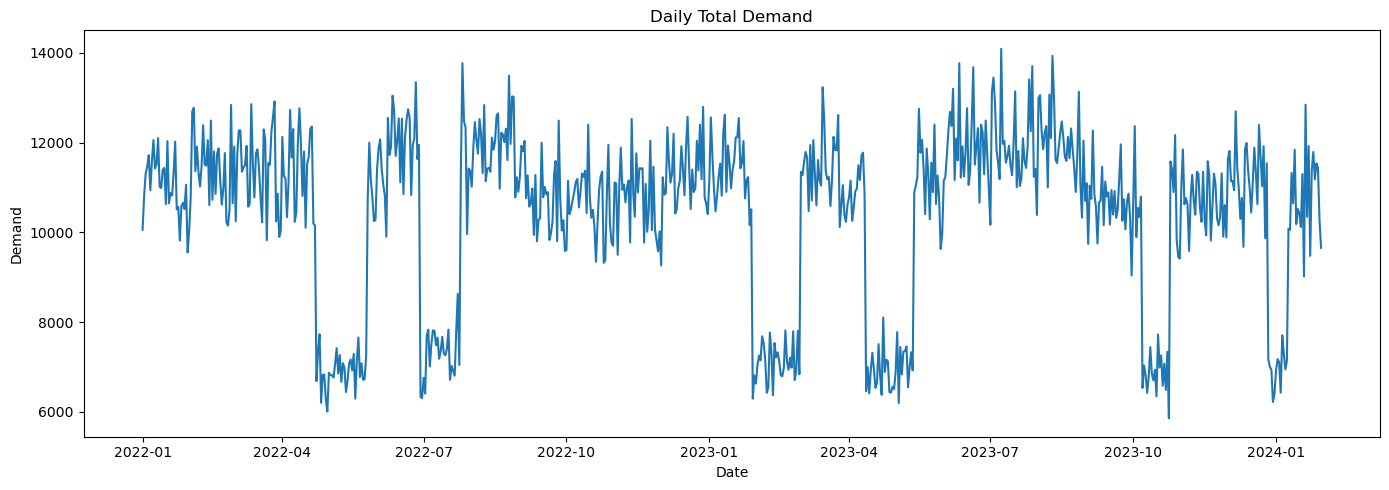

In [30]:
# Plot daily demand

plt.figure(figsize=(14, 5))

plt.plot(
    daily_summary["Date"],
    daily_summary["Total_Demand"]
)

plt.title("Daily Total Demand")
plt.xlabel("Date")
plt.ylabel("Demand")

plt.tight_layout()
plt.show()

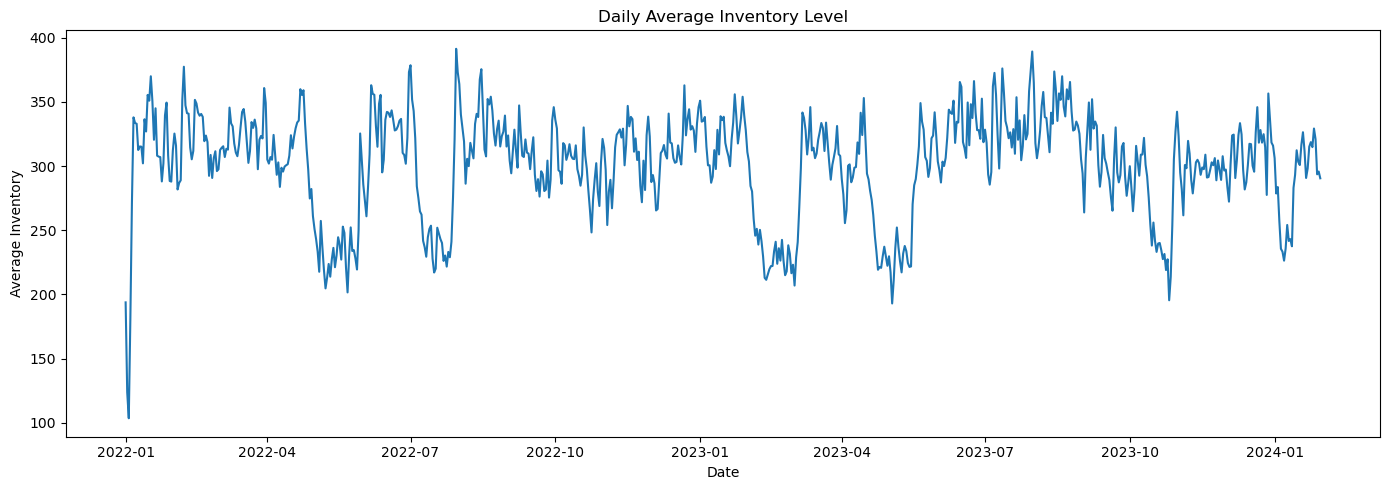

In [31]:
# Plot average inventory

plt.figure(figsize=(14, 5))

plt.plot(
    daily_summary["Date"],
    daily_summary["Average_Inventory"]
)

plt.title("Daily Average Inventory Level")
plt.xlabel("Date")
plt.ylabel("Average Inventory")

plt.tight_layout()
plt.show()

## 14. Promotion vs Demand

In [32]:
# Compare demand during promotion vs no promotion

promotion_demand = (
    df.groupby("Promotion")
    .agg(
        Average_Demand=("Demand", "mean"),
        Total_Demand=("Demand", "sum"),
        Average_Units_Sold=("Units Sold", "mean"),
        Total_Units_Sold=("Units Sold", "sum")
    )
)

promotion_demand

,Average_Demand,Total_Demand,Average_Units_Sold,Total_Units_Sold
Promotion,,,,
0,95.026843,4846369,81.833314,4173499
1,123.269400,3081735,103.095080,2577377


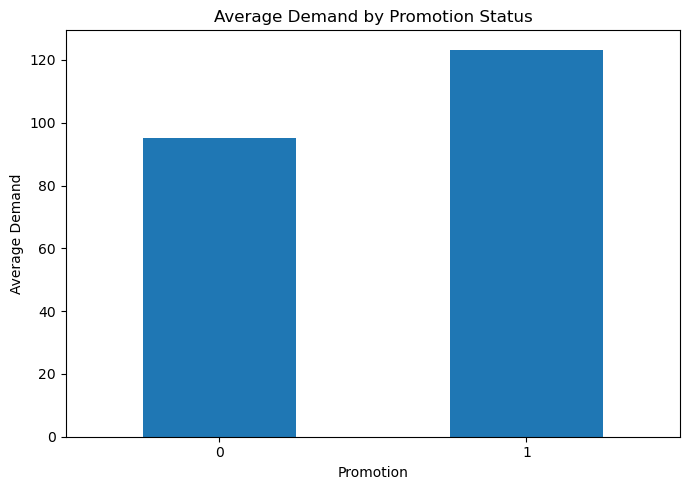

In [33]:
# Visualize average demand by promotion status

plt.figure(figsize=(7, 5))

promotion_demand["Average_Demand"].plot(kind="bar")

plt.title("Average Demand by Promotion Status")
plt.xlabel("Promotion")
plt.ylabel("Average Demand")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 15. Competitor Price Comparison

In [34]:
# Price difference compared with competitor

df["Competitor_Price_Difference"] = (
    df["Price"] - df["Competitor Pricing"]
)

df["Competitor_Price_Difference_Percent"] = np.where(
    df["Competitor Pricing"] != 0,
    (df["Price"] - df["Competitor Pricing"]) /
    df["Competitor Pricing"] * 100,
    np.nan
)

df[[
    "Price",
    "Competitor Pricing",
    "Competitor_Price_Difference",
    "Competitor_Price_Difference_Percent"
]].head()

,Price,Competitor Pricing,Competitor_Price_Difference,Competitor_Price_Difference_Percent
0,72.72,85.73,-13.01,-15.175551
1,80.16,92.02,-11.86,-12.888502
2,62.94,60.08,2.86,4.760320
3,87.63,85.19,2.44,2.864186
4,54.41,51.63,2.78,5.384466


## 16. Save the Stage 2 Dataset

In [35]:
# Save the engineered dataset

output_file = "retail_inventory_stage2.csv"

df.to_csv(output_file, index=False)

print(f"Stage 2 dataset saved as: {output_file}")
print("Final shape:", df.shape)

Stage 2 dataset saved as: retail_inventory_stage2.csv
Final shape: (76000, 38)


In [36]:
# Save summary tables

product_inventory_summary.to_csv(
    "product_inventory_summary.csv"
)

store_inventory_summary.to_csv(
    "store_inventory_summary.csv"
)

category_inventory_summary.to_csv(
    "category_inventory_summary.csv"
)

daily_summary.to_csv(
    "daily_inventory_summary.csv",
    index=False
)

print("Summary tables exported successfully.")

Summary tables exported successfully.
